In [14]:
from pyarrow import dataset as ds
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

### load data

In [15]:
dataset = ds.dataset("../data/renovation-data-all.parquet", format="parquet")
table = dataset.to_table(columns=None, use_threads=True)
df = table.to_pandas()
df.head()

,entity_id,epc_before,ontology.building.building_general.construction_year,ontology.building.building_general.floor_area,ontology.building.pv.available_roof_area_for_solar_panel_in_m2,ontology.building.pv.has_pv,steps,has_insulate_exterior_inclined_roof,has_insulate_exterior_flat_roof,has_insulate_exterior_wall,...,ontology.building.systems.space_heating_emission_systems.CONVECTOR,ontology.building.systems.space_heating_emission_systems.FLOOR,ontology.building.systems.space_heating_emission_systems.AIR,ontology.building.systems.space_heating_emission_systems.LOCAL_STOVE,ontology.building.envelope.insulation_level_roof_extension_MODERATELY_INSULATED,ontology.building.envelope.insulation_level_roof_main_MODERATELY_INSULATED,ontology.building.systems.space_heating_generation_on_electricity.CENTRAL_HEAT_PUMP,ontology.building.systems.space_heating_generation_on_electricity.LOCAL_RESISTANCE_HEATERS,ontology.building.envelope.basement_occurance_PARTIAL,ontology.building.envelope.floor_boundary_types.BASEMENT_OR_CRAWLSPACE
0,0,394,1965.0,203.0,8.0,0,"[insulate_floors_above_air_from_below, insulat...",1,1,1,...,1,0,0,0,0,0,0,0,0,1
1,1,413,1969.0,226.0,16.0,0,"[insulate_floors_above_air_from_below, insulat...",1,1,1,...,1,0,1,0,1,0,0,0,0,1
2,2,469,1967.0,195.0,71.0,0,"[insulate_exterior_inclined_roof, replace_sing...",1,1,1,...,0,0,0,0,1,0,0,0,0,1
3,3,592,1969.0,220.0,63.0,0,"[insulate_floors_above_air_from_below, replace...",0,1,0,...,1,1,0,0,0,0,0,0,0,1
4,5,511,1967.0,173.0,25.0,0,"[replace_epump_with_dhw, insulate_floors_above...",1,1,1,...,0,0,0,1,1,1,0,0,0,1


In [16]:
steps_encoding = {
    'insulate_exterior_inclined_roof': 1,
    'insulate_exterior_flat_roof': 2,
    'insulate_exterior_wall': 3,
    'insulate_cavity_wall': 4,
    'insulate_floors_above_air_from_below': 5,
    'replace_single_and_old_double_for_hr_glass_with_new_frames': 6,
    'replace_non_condensing_gas_boiler_with_condensing_gas_boiler': 7,
    'replace_epump_with_dhw': 8,
    'install_pv_panels': 9,  
}

def plot_heatmap(M, found_steps):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(M, cmap='Greens')

    ax.set_xticks(np.arange(len(found_steps)))
    ax.set_yticks(np.arange(len(found_steps)))
    ax.set_xticklabels(found_steps)
    ax.set_yticklabels(found_steps)

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=8)

    for i, j in np.ndindex(M.shape):
        ax.text(j, i, f"{M[i][j]:.2f}", ha="center", va="center", 
                color="w" if M[i][j] > 0.35 else "black")

    ax.set_ylabel("from state")
    ax.set_xlabel("to state")
    plt.show()


### add targets and encode them

In [17]:
df["steps_encoded"] = df["steps"].apply(lambda x: [steps_encoding[step] for step in x])
df[['steps', 'steps_encoded']].head(10)

,steps,steps_encoded
0,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 6, 2, 9, 3]"
1,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 6, 2, 9, 3]"
2,"[insulate_exterior_inclined_roof, replace_sing...","[1, 6, 2, 9, 3]"
3,"[insulate_floors_above_air_from_below, replace...","[5, 6, 2, 4, 9]"
4,"[replace_epump_with_dhw, insulate_floors_above...","[8, 5, 1, 6, 2, 3, 9]"
5,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 9, 3]"
6,"[insulate_exterior_inclined_roof, replace_sing...","[1, 6, 2, 3]"
7,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 6, 9, 3]"
8,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 6, 2, 4, 9, 7]"
9,"[insulate_floors_above_air_from_below, insulat...","[5, 1, 6, 4, 9]"


## create transition matrix

In [18]:
# count transition pairs
pair_counter = Counter()
for steps in df['steps_encoded']:
    for i in range(len(steps) - 1):
        pair = (steps[i], steps[i + 1])
        pair_counter[pair] += 1
        
# count outgoing transitions from each state
outgoing_counts = Counter()
for (state_from, state_to), count in pair_counter.items():
    outgoing_counts[state_from] += count

# probability of transitioning from one state to another
states = [i for i in range(1, 10)]
probabilities = {s: {} for s in states}

for (state_from, state_to), count in pair_counter.items():
    probabilities[state_from][state_to] = count / outgoing_counts[state_from]

In [19]:
state_index = {s: i for i, s in enumerate(states)}
transition_matrix = np.zeros((len(states), len(states)))

for s_from, transitions in probabilities.items():
    i = state_index[s_from]
    for s_to, prob in transitions.items():
        j = state_index[s_to]
        transition_matrix[i, j] = prob

# save matrix
np.save("../models/transition_matrix.npy", transition_matrix)

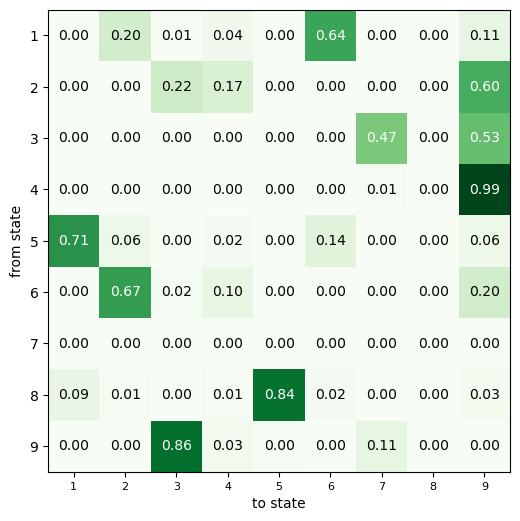

In [20]:
plot_heatmap(transition_matrix, probabilities.keys())